In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv("house_price_regression_dataset.csv")

In [ ]:
df.head()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [32]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [34]:
df["Num_Bedrooms"].value_counts()

Num_Bedrooms
2    215
5    205
1    201
4    197
3    182
Name: count, dtype: int64

In [36]:
df["Garage_Size"].value_counts()

Garage_Size
2    343
1    336
0    321
Name: count, dtype: int64

In [38]:
for column in df.columns:
    print(df[column].value_counts())

Square_Footage
3419    3
4219    3
4646    3
1743    3
2292    2
       ..
1269    1
4926    1
966     1
3592    1
4272    1
Name: count, Length: 894, dtype: int64
Num_Bedrooms
2    215
5    205
1    201
4    197
3    182
Name: count, dtype: int64
Num_Bathrooms
1    350
2    327
3    323
Name: count, dtype: int64
Year_Built
1996    24
1977    22
2008    21
1983    21
2017    21
        ..
1980     8
2001     8
2020     8
1951     6
1963     5
Name: count, Length: 73, dtype: int64
Lot_Size
3.108790    1
0.599637    1
4.753014    1
3.634823    1
2.730667    1
           ..
4.781489    1
3.978440    1
3.555040    1
3.941604    1
1.014286    1
Name: count, Length: 1000, dtype: int64
Garage_Size
2    343
1    336
0    321
Name: count, dtype: int64
Neighborhood_Quality
10    123
5     109
2     105
7     102
6     101
4      99
8      97
1      91
9      88
3      85
Name: count, dtype: int64
House_Price
742599.253332    1
262382.852274    1
985260.854490    1
777977.390119    1
229698.91866

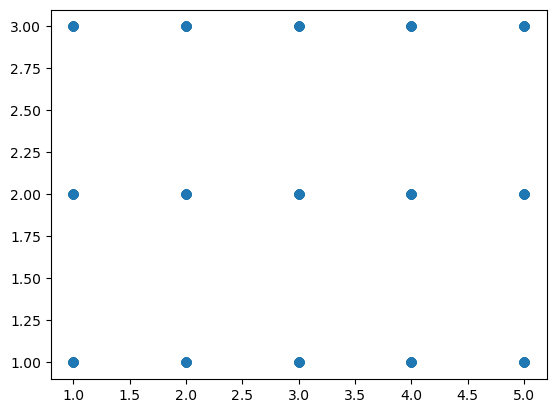

In [40]:
plt.scatter(df["Num_Bedrooms"], df["Num_Bathrooms"])
plt.show()

In [42]:
X = df.drop("House_Price", axis = 1)
y = df["House_Price"]

In [ ]:
from sklearn.model_selection import train_test_split

In [188]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 10)

In [189]:
from sklearn.preprocessing import StandardScaler
cols_for_scale = ["Square_Footage","Num_Bedrooms","Num_Bathrooms","Year_Built","Lot_Size","Garage_Size","Neighborhood_Quality"]
scaler = StandardScaler()
X_train[cols_for_scale] =scaler.fit_transform(X_train[cols_for_scale])
X_test[cols_for_scale] =scaler.transform(X_test[cols_for_scale]) 

In [190]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [191]:
tree_model = DecisionTreeRegressor()

In [192]:
tree_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [193]:
y_pred = tree_model.predict(X_test)

In [194]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [195]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate regression metrics
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

print("Regression Report:", regression_report(y_test, y_pred))

Mean Squared Error: 1150713243.5246537
Mean Absolute Error: 26376.16786350048
R² Score: 0.9811484070052873
Regression Report: {'MSE': 1150713243.5246537, 'RMSE': np.float64(33922.164487612725), 'MAE': 26376.16786350048, 'R²': 0.9811484070052873}


# Hyperparameter Tuning

In [196]:
param = {
    "criterion": ["squared_error","absolute_error","poisson"],
    "splitter" :["best","random"],
    "max_depth" : [1,2,3,4,5,15,None],
    "max_features" : ["sqrt","log2",None]
}

In [197]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator= DecisionTreeRegressor() , param_grid=param, cv=5)

In [198]:
import warnings
warnings.filterwarnings("ignore")
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 15, None],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']})

In [199]:
grid.best_params_

{'criterion': 'poisson',
 'max_depth': 15,
 'max_features': None,
 'splitter': 'best'}

In [187]:
y_pred_grid = grid.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_grid))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_grid))
print("R² Score:", r2_score(y_test, y_pred_grid))

Mean Squared Error: 1118493914.3327036
Mean Absolute Error: 26026.692171403556
R² Score: 0.9824809781159148
